In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 80)

plt.style.use('seaborn-v0_8-whitegrid')

In [4]:
# Data Loading 
df = pd.read_csv('../Data/Raw/developer-survey-2025.csv', low_memory=False)

print(f"Shape: {df.shape}")
print(f"Column count: {len(df.columns)}")
print(f"First 5 column names: {list(df.columns[:5])}")

Shape: (49191, 172)
Column count: 172
First 5 column names: ['ResponseId', 'MainBranch', 'Age', 'EdLevel', 'Employment']


In [5]:
# Y = mx + C - Linear regression 
target_col = 'ConvertedCompYearly'
print(f"Target column present: {target_col in df.columns}")

Target column present: True


In [6]:
df[target_col].describe()

count    2.394700e+04
mean     1.017615e+05
std      4.617569e+05
min      1.000000e+00
25%      3.817100e+04
50%      7.532000e+04
75%      1.205960e+05
max      5.000000e+07
Name: ConvertedCompYearly, dtype: float64

In [7]:
## Check the percentage of salaries available
salary_available = df[target_col].notna().sum() ## We have a value in a row
salary_missing = df[target_col].isna().sum() # We do not have a value in this rows

print(f'Rows with salary: {salary_available}')
print(f"Rows without salary: {salary_missing}")
print(f"Coverage : {salary_available/len(df) * 100:.1f}%")

Rows with salary: 23947
Rows without salary: 25244
Coverage : 48.7%


In [8]:
print(len(df))

49191


In [9]:
## Dropping empty rows

df[target_col].dropna().describe()


count    2.394700e+04
mean     1.017615e+05
std      4.617569e+05
min      1.000000e+00
25%      3.817100e+04
50%      7.532000e+04
75%      1.205960e+05
max      5.000000e+07
Name: ConvertedCompYearly, dtype: float64

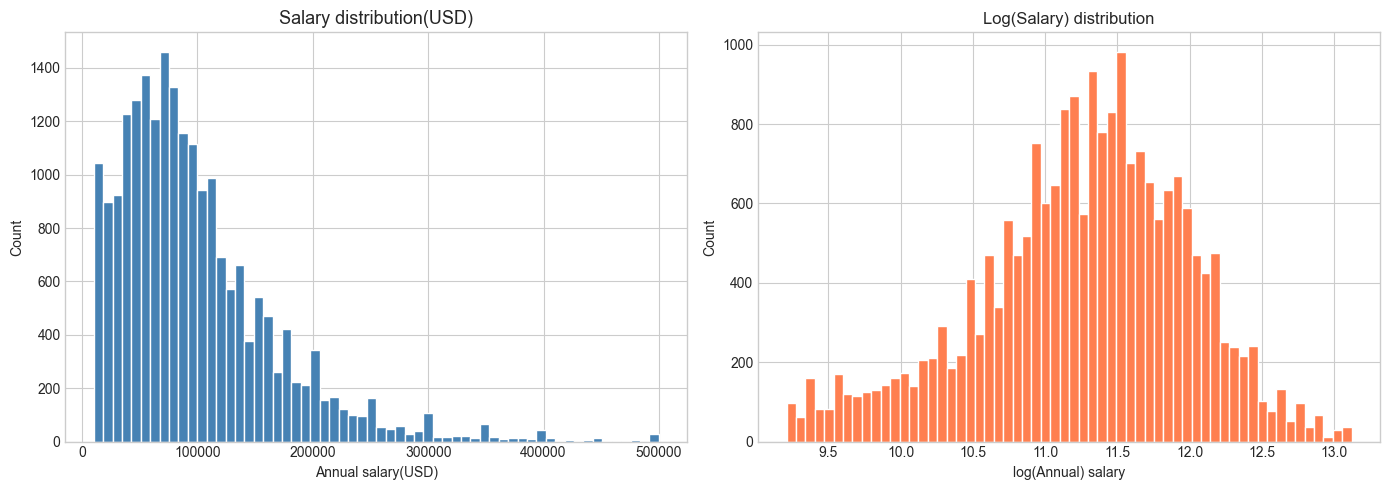

Median salary: $81,870
Mean salary: $98,572


In [10]:
# Visualize dataset limiting ourself to rows with values withing the range 

salary_df = df[df[target_col].between(10000, 500000)] # Filtering rows with values in that range

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# raw distribution
axes[0].hist(salary_df[target_col], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Salary distribution(USD)', fontsize=13)
axes[0].set_xlabel('Annual salary(USD)')
axes[0].set_ylabel('Count')

#log-scale distribution
axes[1].hist(np.log1p(salary_df[target_col]), bins=60, color='coral', edgecolor='white')
axes[1].set_title('Log(Salary) distribution')
axes[1].set_xlabel('log(Annual) salary')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../Data/salary_distribution.png', dpi=300)
plt.show()

print(f"Median salary: ${salary_df[target_col].median():,.0f}")
print(f'Mean salary: ${salary_df[target_col].mean():,.0f}')



In [11]:
# Explore the selected features.
features = ['Country', 'YearsCodePro', 'Edlevel', 'Employment', 'LanguageHaveWorkedWith']
for col in features:
    if col in df.columns:
        missing_pct = df[col].isna().mean() * 100
        unique_count = df[col].nunique() #nunique - returns the number of unique items (int), .unique() returns the actual unique items.
 
        print("Column", col)
        print("Missing, ", missing_pct)
        print("Unique values count: ", unique_count)
        print(" First 5 rows: ")
        print(df[col].value_counts().head().to_string())
        print()

Column Country
Missing,  27.96039926002724
Unique values count:  177
 First 5 rows: 
Country
United States of America                                7233
Germany                                                 3025
India                                                   2547
United Kingdom of Great Britain and Northern Ireland    2042
France                                                  1409

Column Employment
Missing,  1.7320241507592853
Unique values count:  6
 First 5 rows: 
Employment
Employed                                                33750
Independent contractor, freelancer, or self-employed     6708
Student                                                  4428
Not employed                                             2227
Retired                                                   708

Column LanguageHaveWorkedWith
Missing,  35.6162712691346
Unique values count:  15478
 First 5 rows: 
LanguageHaveWorkedWith
HTML/CSS;JavaScript;TypeScript           370
Python                 

C:\Users\Doris\AppData\Local\Temp\ipykernel_3500\1519386427.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


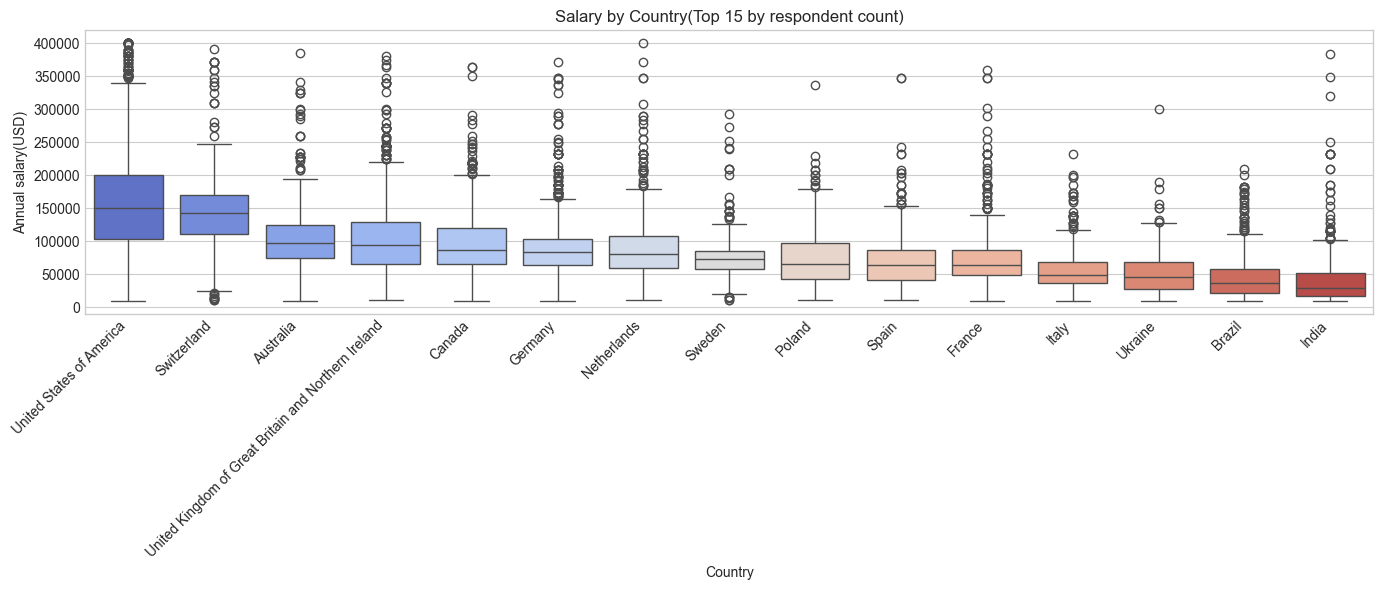

In [12]:
df_sal = df[df[target_col].between(10_000, 400_000)].copy()  #.between returns boolean
 
top_countries = df_sal['Country'].value_counts().head(15).index  #.index removes the count
country_data = df_sal[df_sal['Country'].isin(top_countries)]
 
plt.figure(figsize=(14, 6))
order = country_data.groupby('Country')[target_col].median().sort_values(ascending=False).index
 
sns.boxplot(
    data=country_data,
    x='Country', y=target_col,
    order=order,
    palette='coolwarm')
 
plt.xticks(rotation=45, ha='right')
plt.title('Salary by Country(Top 15 by respondent count)')
plt.ylabel('Annual salary(USD)')
plt.tight_layout()
plt.savefig('../data/salary_by_country.png', dpi=300)
plt.show()

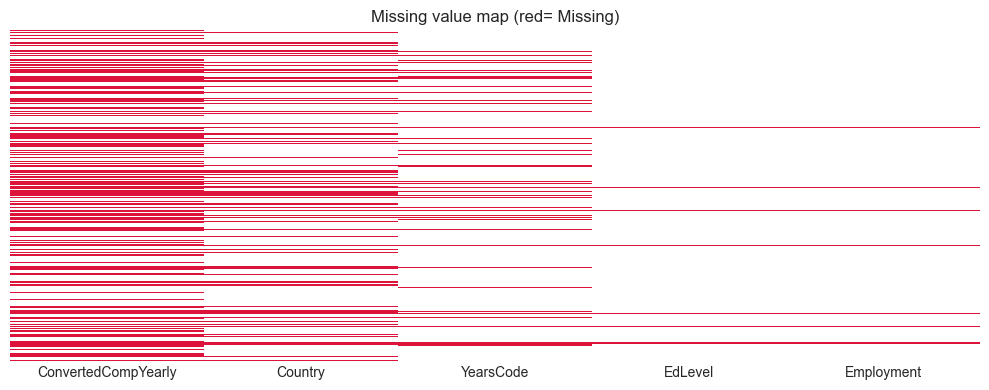

In [16]:
selected_cols = [target_col, 'Country', 'YearsCode', 'EdLevel', 'Employment']
available_cols = [c for c in selected_cols if c in df.columns]  
 
missing_df = df[available_cols].isna()
 
plt.figure(figsize=(10, 4))
sns.heatmap(missing_df.sample(min(1000, len(df)), random_state=42),
            cbar=False, yticklabels=False, xticklabels=True,
            cmap=['white', 'crimson'])
plt.title('Missing value map (red= Missing)')
plt.tight_layout()
plt.show()